In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree


In [16]:
f1 = '/Users/potato/Downloads/plt59000_flame_iso_c05_flamefront_points.csv'
f2 = '/Users/potato/Downloads/plt59250_flame_iso_c05_flamefront_points.csv'
df1 = pd.read_csv(f1)
df2 = pd.read_csv(f2)

In [17]:
tree_59000 = cKDTree(df1[["y", "z"]].values)

In [24]:
dist_yz, idx_nearest = tree_59000.query(df2[["y", "z"]].values, k=1)
df_out = df2.copy()

df_out["nearest_idx_59000"] = idx_nearest
df_out["x_59000_nearest"] = df1.iloc[idx_nearest]["x"].values
df_out["yz_dist"] = dist_yz
dx = df_out["x_59000_nearest"] - df_out["x"] 
# negative value: backward
# positive value: forward
# stationary
movement = []
markers= []
for i in range(len(dx)):
    if (dx[i]>0):
        # forward
        movement.append(1)
        markers.append('<')
    elif(dx[i]<0):
        movement.append(-1)
        markers.append('>')
    else:
        movement.append(0)
        markers.append('.')
df_out["dx"] =  dx
df_out['displacement']=movement

In [26]:
df_f = df_out[df_out['displacement'] ==1]
df_b = df_out[df_out['displacement'] ==-1]
df_s = df_out[df_out['displacement'] ==0]

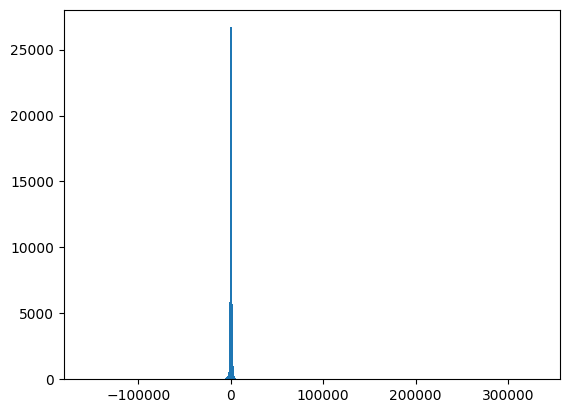

mean value of forward curvature 338.80090358899344 
median value of forward curvature 227.17343026967703 
std value of forward curvature 2742.3007137719633 


In [35]:
plt.hist(df_f['curvature'],bins=400)
plt.show()
print(f"mean value of forward curvature {np.mean(df_f['curvature'])} ")
print(f"median value of forward curvature {np.median(df_f['curvature'])} ")
print(f"std value of forward curvature {np.std(df_f['curvature'])} ")

In [59]:
def count_value(list1:list):
    # values [ -1000,-100,-10,-1,0,1,10,100,1000]
    list1 = np.array(list1)
    cts = {"-10e3+":0, "-10e3e2":0,"-10e2e1":0, "-10e1e0":0, "-1_0":0, "1_0":0 ,"10e0e1":0, "10e1e2":0,"10e2e3":0, "10e3+":0 }
    for i in range(len(list1)):
        tv = list1[i]
        #print(tv)
        if(tv<= -1000):
            cts['-10e3+']+=1
        elif( tv>-1000 and tv<= -100):
            cts['-10e3e2'] +=1
        elif( tv>-100 and tv<= -10):
            cts['-10e2e1'] +=1
        elif( tv>-10 and tv<= -1):
            cts['-10e1e0'] +=1
        elif( tv>-1 and tv <= 0):
            cts['-1_0'] +=1
        elif( tv>0 and tv<= 1):
            cts['1_0'] +=1
        elif( tv>1 and tv<= 10):
            cts['10e0e1'] +=1
        elif( tv>10 and tv<= 100):
            cts['10e1e2'] +=1
        elif( tv>100 and tv<= 100):
            cts['10e2e3'] +=1
        else :
            cts['10e3+'] +=1

    return cts

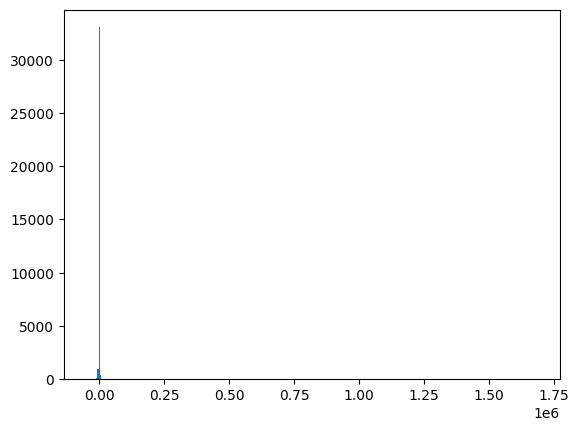

mean value of backward curvature 54.790613610438136 
median value of backward curvature -8.725629889327394 
std value of backward curvature 9301.941294077484 


In [50]:
plt.hist(np.array(df_b['curvature']),bins=400)
plt.show()

print(f"mean value of backward curvature {np.mean(df_b['curvature'])} ")
print(f"median value of backward curvature {np.median(df_b['curvature'])} ")
print(f"std value of backward curvature {np.std(df_b['curvature'])} ")

In [60]:
count_value(df_b['curvature'])

{'-10e3+': 2466,
 '-10e3e2': 11855,
 '-10e2e1': 2928,
 '-10e1e0': 336,
 '-1_0': 42,
 '1_0': 45,
 '10e0e1': 319,
 '10e1e2': 2546,
 '10e2e3': 0,
 '10e3+': 14078}

In [61]:
count_value(df_f['curvature'])

{'-10e3+': 1737,
 '-10e3e2': 7879,
 '-10e2e1': 3627,
 '-10e1e0': 466,
 '-1_0': 53,
 '1_0': 64,
 '10e0e1': 426,
 '10e1e2': 3008,
 '10e2e3': 0,
 '10e3+': 23661}

In [62]:
count_value(df_s['curvature'])

{'-10e3+': 48,
 '-10e3e2': 223,
 '-10e2e1': 61,
 '-10e1e0': 7,
 '-1_0': 3,
 '1_0': 1,
 '10e0e1': 10,
 '10e1e2': 59,
 '10e2e3': 0,
 '10e3+': 520}

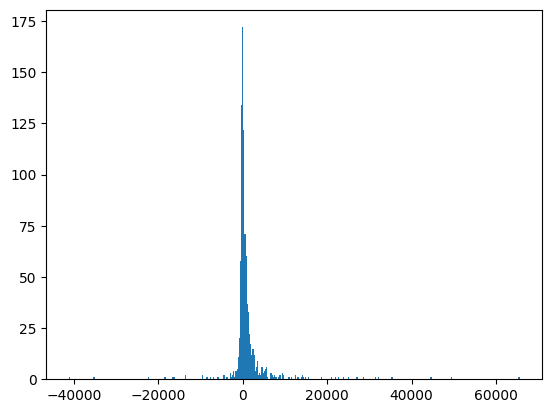

mean value of stable curvature 338.80090358899344 
median value of stable curvature 227.17343026967703 
std value of stable curvature 2742.3007137719633 


In [38]:
plt.hist(df_s['curvature'],bins=400)
plt.show()
print(f"mean value of stable curvature {np.mean(df_f['curvature'])} ")
print(f"median value of stable curvature {np.median(df_f['curvature'])} ")
print(f"std value of stable curvature {np.std(df_f['curvature'])} ")